# 10 · Routing Audit & ORF5 Extraction Demo

**Purpose.** Two things reviewers will ask for around the *alias-aware routing* novelty:
1. **Routing audit** — prove the router sends records with usable annotation to **direct** extraction and records without to **tblastn** lifting (not just that accuracy is high).
2. **ORF5 use-case demo** — the motivating downstream task: extract ORF5 (GP5) across the *entire* PRRSV set, including records that are unannotated or use a different gene name, and report coverage.

## Inputs

FMD/PRRS/PED annotated query sets + references (routing audit); full PRRSV set (ORF5 demo).

In [1]:
from pathlib import Path
from copy import deepcopy
import sys, random

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "app" / "src").exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA = ROOT / "app" / "data"

FMD_REF    = DATA / "FMD"  / "FMD_ref_test.gb"
FMD_QUERY  = DATA / "FMD"  / "FMD_100seq_anno.gb"
PRRS_REF   = DATA / "PRRS" / "PRRS_ref_test.gb"
PRRS_QUERY = DATA / "PRRS" / "PRRS_100seq_anno.gb"
PED_REF    = DATA / "PED"  / "PED_ref_1.gb"
PED_QUERY  = DATA / "PED"  / "PED_100seqs.gb"

FMD_NOANNO  = DATA / "FMD"  / "FMD_OQ211398_noAnno.gb"
PRRS_NOANNO = DATA / "PRRS" / "PRRS_PP946131_noAnno.gb"

SEED = 20260819      # de-annotation draw for the mixed corpus
STRIP_FRACTION = 0.3

In [2]:
UNIT_DIR = ROOT / "app" / "validation" / "06_run_tool_extract"
OUT = UNIT_DIR / "outputs"
OUT.mkdir(parents=True, exist_ok=True)
print("outputs ->", OUT)

outputs -> /root/work/app/validation/06_run_tool_extract/outputs


## Setup

In [3]:
from app.src.io.genbank_parser import load_genbank_records, load_single_genbank
from app.src.features.annotation_strategy import get_strategy
from app.src.features.direct_extractor import direct_extract_with_alias
from app.src.lifting.tblastn_lifter import lift_all_tblastn
from app.src.pipeline import PipelineConfig
from app.validation._shared.validation_utils import (
    load_reference_bundle, lifted_to_rows, parse_features_for_type,
)
from app.src.alias.gene_alias import apply_alias_to_features

CFG = PipelineConfig()

def annotate_record(rec, bundle):
    """Run the tool exactly as production does: route, then take that branch."""
    ftype = bundle["feature_type"]
    strategy, qtype = get_strategy(rec, bundle["alias_lookup"],
                                   allowed_types=(ftype,) if ftype else None)
    if strategy == "direct":
        feats = direct_extract_with_alias(rec, qtype or ftype, bundle["features"], bundle["alias_lookup"])
    else:
        feats = lift_all_tblastn(ref_features=bundle["features"], ref_record=bundle["record"],
                                 query_record=rec, min_coverage=CFG.min_coverage,
                                 min_identity=CFG.min_identity, evalue=CFG.evalue,
                                 rescue_window=CFG.rescue_window, validate_codons=(ftype == "CDS"))
    return strategy, lifted_to_rows(rec.id, feats, strategy)

## Part A — Routing audit

For each record: what did the router decide, and does that match the record's actual annotation status (how many gene names resolve to canonical via the alias map)?

In [4]:
DATASETS = {"fmd": (FMD_REF, FMD_QUERY), "prrs": (PRRS_REF, PRRS_QUERY), "ped": (PED_REF, PED_QUERY)}

audit = []
for label, (ref_path, query_path) in DATASETS.items():
    bundle = load_reference_bundle(ref_path)
    ftype = bundle["feature_type"]
    for rec in load_genbank_records(query_path):
        # count at the reference's own feature level (CDS for PRRSV/PEDV, mat_peptide for FMDV)
        feats = apply_alias_to_features(parse_features_for_type(rec, ftype), bundle["alias_lookup"])
        n_resolved = sum(f.get("name_source") in ("alias", "alias_conflict_resolved") for f in feats)
        strategy, qtype = get_strategy(rec, bundle["alias_lookup"], allowed_types=(ftype,) if ftype else None)
        audit.append({"virus": label, "record_id": rec.id,
                      "n_features": len(feats), "n_resolved_names": n_resolved,
                      "has_useful_annotation": n_resolved > 0,
                      "routed_to": strategy, "feature_type": qtype})

        # same record with its annotation removed -> must flip to tblastn
        bare = deepcopy(rec); bare.features = []
        s_bare, _ = get_strategy(bare, bundle["alias_lookup"], allowed_types=(ftype,) if ftype else None)
        audit[-1]["routed_to_when_stripped"] = s_bare

audit_df = pd.DataFrame(audit)
audit_df.to_csv(OUT / "routing_audit.tsv", sep="\t", index=False)

crosstab = pd.crosstab(audit_df["has_useful_annotation"], audit_df["routed_to"])
crosstab.to_csv(OUT / "routing_crosstab.tsv", sep="\t")
print("annotated records -> route:"); print(crosstab.to_string())
print("\nsame records, annotation stripped -> route:",
      audit_df["routed_to_when_stripped"].value_counts().to_dict())
crosstab

annotated records -> route:
routed_to              direct  tblastn
has_useful_annotation                 
False                       0        4
True                      296        0

same records, annotation stripped -> route: {'tblastn': 300}


routed_to,direct,tblastn
has_useful_annotation,,
False,0,4
True,296,0


## Expected pattern & consistency check

`has_useful_annotation=True` → `direct`; `False` → `tblastn`. Flag any record that violates this so it can be inspected.

In [5]:
audit_df["consistent"] = ((audit_df["has_useful_annotation"] & (audit_df["routed_to"] == "direct")) |
                          (~audit_df["has_useful_annotation"] & (audit_df["routed_to"] == "tblastn")))
violations = audit_df[~audit_df["consistent"]]
print(f"{len(violations)} routing inconsistencies out of {len(audit_df)} records")
violations.head(20)

0 routing inconsistencies out of 300 records


,virus,record_id,n_features,n_resolved_names,has_useful_annotation,routed_to,feature_type,routed_to_when_stripped,consistent


## Part B — ORF5 extraction across a **mixed** PRRSV corpus

The motivating downstream task, on the corpus shape the tool is actually built for: some records
fully annotated, some annotated under different names, some with **no annotation at all**.

The corpus here is the 100 PRRSV records with a fixed random **30 % de-annotated**
(`random.Random(20260819)`), plus the genuinely unannotated `PRRS_PP946131_noAnno.gb`. Coverage is
the fraction of records for which the tool produced an ORF5 — the number a primer-design pipeline
actually cares about.

Canonical token is `ORF5`; `GP5` and other submitted spellings normalise to it through the alias map.

In [6]:
ORF5_NAMES = {"ORF5"}

bundle = load_reference_bundle(PRRS_REF)
records = load_genbank_records(PRRS_QUERY)

rng = random.Random(SEED)
strip_ids = set(rng.sample([r.id for r in records], int(len(records) * STRIP_FRACTION)))

corpus = []
for rec in records:
    if rec.id in strip_ids:
        bare = deepcopy(rec); bare.features = []
        corpus.append(("de-annotated", bare))
    else:
        corpus.append(("as submitted", rec))
corpus.append(("real noAnno file", load_single_genbank(PRRS_NOANNO)))
print(f"mixed corpus: {len(corpus)} records "
      f"({len(strip_ids)} de-annotated, {len(records)-len(strip_ids)} as submitted, 1 real noAnno)")

orf5_rows = []
for kind, rec in corpus:
    strategy, preds = annotate_record(rec, bundle)
    hit = next((p for p in preds if str(p.get("pred_name")) in ORF5_NAMES and p.get("pred_start")), None)
    orf5_rows.append({"record_id": rec.id, "record_kind": kind, "routed_to": strategy,
                      "orf5_found": hit is not None,
                      "start": hit["pred_start"] if hit else None,
                      "end": hit["pred_end"] if hit else None,
                      "length": (hit["pred_end"] - hit["pred_start"] + 1) if hit else None})
orf5_df = pd.DataFrame(orf5_rows)
orf5_df.to_csv(OUT / "orf5_extraction.tsv", sep="\t", index=False)

print(f"\nORF5 recovered in {orf5_df['orf5_found'].sum()}/{len(orf5_df)} records "
      f"({orf5_df['orf5_found'].mean()*100:.1f}%)")
summary = (orf5_df.groupby(["record_kind", "routed_to"])["orf5_found"]
             .agg(found="sum", records="size").reset_index())
summary["pct"] = (summary["found"] / summary["records"] * 100).round(1)
summary.to_csv(OUT / "orf5_by_route.tsv", sep="\t", index=False)
print(summary.to_string(index=False))
print("\nlength of the extracted ORF5 (sanity: PRRSV GP5 is ~603 bp):")
print(orf5_df["length"].describe()[["count","min","50%","max"]].to_string())

mixed corpus: 101 records (30 de-annotated, 70 as submitted, 1 real noAnno)


/usr/local/lib/python3.11/dist-packages/Bio/GenBank/Scanner.py:1215: BiopythonParserWarning: Premature end of file in sequence data
  warnings.warn(



ORF5 recovered in 101/101 records (100.0%)
     record_kind routed_to  found  records   pct
    as submitted    direct     70       70 100.0
    de-annotated   tblastn     30       30 100.0
real noAnno file   tblastn      1        1 100.0

length of the extracted ORF5 (sanity: PRRSV GP5 is ~603 bp):
count    101.0
min      522.0
50%      603.0
max      606.0


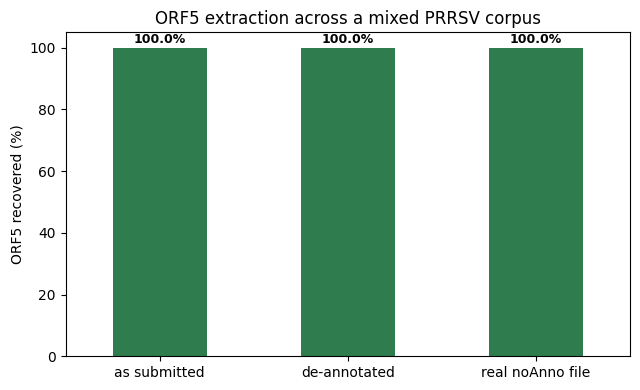

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4))
tab = orf5_df.groupby("record_kind")["orf5_found"].mean().mul(100)
tab.plot.bar(ax=ax, color="#2f7d4f", rot=0)
ax.set_ylabel("ORF5 recovered (%)"); ax.set_ylim(0, 105); ax.set_xlabel("")
ax.set_title("ORF5 extraction across a mixed PRRSV corpus")
for i, v in enumerate(tab): ax.text(i, v + 1.5, f"{v:.1f}%", ha="center", fontweight="bold", fontsize=9)
fig.tight_layout(); fig.savefig(OUT / "orf5_coverage.png", dpi=200, bbox_inches="tight")

## Interpretation

> Fill in after the run. Two separate claims:
> 1. **Routing audit** — records with usable annotation go `direct`; the *same* records with their
>    annotation stripped flip to `tblastn`. Reporting both directions is what makes it an audit
>    rather than a coincidence.
> 2. **ORF5 coverage** — the fraction of a realistically messy corpus for which the primer-design
>    step gets its target gene. This is the end-to-end number the brief's use case asks for, and it
>    is the one to quote in the Introduction.